In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [10]:
housing_data = pd.read_csv("../data/train.csv")
housing_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Exploration des données (EDA)

### 1.1 Dimensions du dataset

In [11]:
rows, cols = housing_data.shape
print(f"Lignes : {rows}")
print(f"Colonnes : {cols}")

Lignes : 1460
Colonnes : 81


### 1.2 Types des colonnes (dtypes)

In [12]:
numeric_cols = housing_data.select_dtypes(include="number").columns.tolist()
categorical_cols = housing_data.select_dtypes(include="object").columns.tolist()

print(f"Colonnes numériques ({len(numeric_cols)}) : {numeric_cols}")
print(f"Colonnes catégorielles ({len(categorical_cols)}) : {categorical_cols}")

Colonnes numériques (38) : ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
Colonnes catégorielles (43) : ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functi

### 1.3 Statistiques descriptives (describe)

In [13]:
housing_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 1.4 Distribution de la variable cible — SalePrice

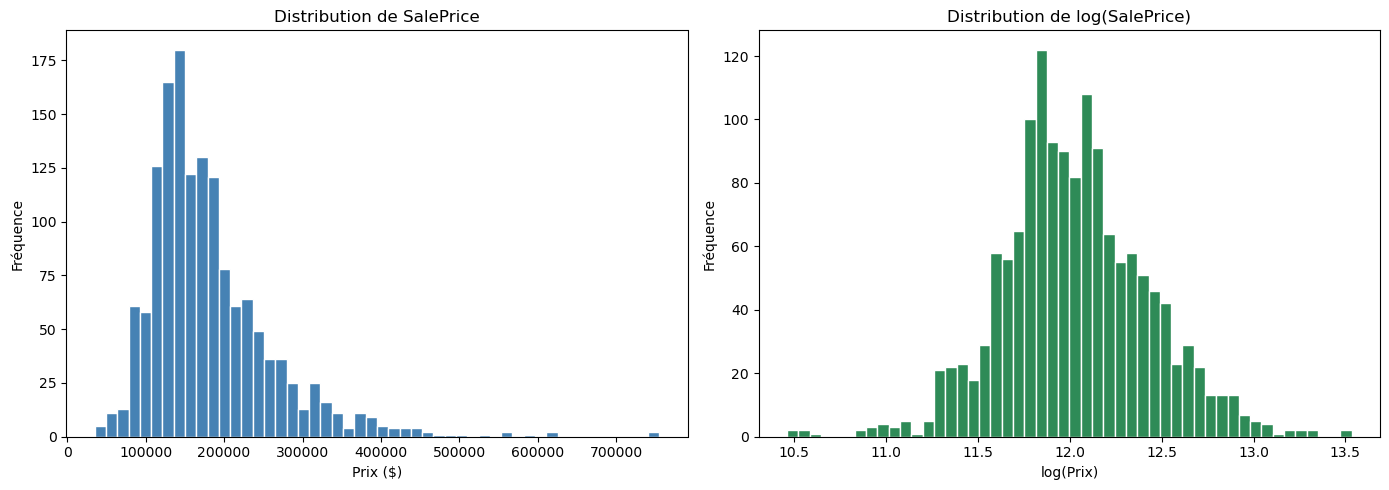

Skewness   : 1.8829  (> 0 = asymétrie à droite)
Kurtosis   : 6.5363  (> 3 = queues lourdes)
Skewness log-transformé : 0.1213


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(housing_data["SalePrice"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution de SalePrice")
axes[0].set_xlabel("Prix ($)")
axes[0].set_ylabel("Fréquence")


axes[1].hist(np.log1p(housing_data["SalePrice"]), bins=50, color="seagreen", edgecolor="white")
axes[1].set_title("Distribution de log(SalePrice)")
axes[1].set_xlabel("log(Prix)")
axes[1].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

skewness = housing_data["SalePrice"].skew()
kurtosis = housing_data["SalePrice"].kurt()
print(f"Skewness   : {skewness:.4f}  (> 0 = asymétrie à droite)")
print(f"Kurtosis   : {kurtosis:.4f}  (> 3 = queues lourdes)")
print(f"Skewness log-transformé : {np.log1p(housing_data['SalePrice']).skew():.4f}")

### 1.5 Valeurs manquantes

              NaN count  Pourcentage
PoolQC             1453        99.52
MiscFeature        1406        96.30
Alley              1369        93.77
Fence              1179        80.75
MasVnrType          872        59.73
FireplaceQu         690        47.26
LotFrontage         259        17.74
GarageType           81         5.55
GarageYrBlt          81         5.55
GarageFinish         81         5.55
GarageQual           81         5.55
GarageCond           81         5.55
BsmtExposure         38         2.60
BsmtFinType2         38         2.60
BsmtQual             37         2.53
BsmtCond             37         2.53
BsmtFinType1         37         2.53
MasVnrArea            8         0.55
Electrical            1         0.07


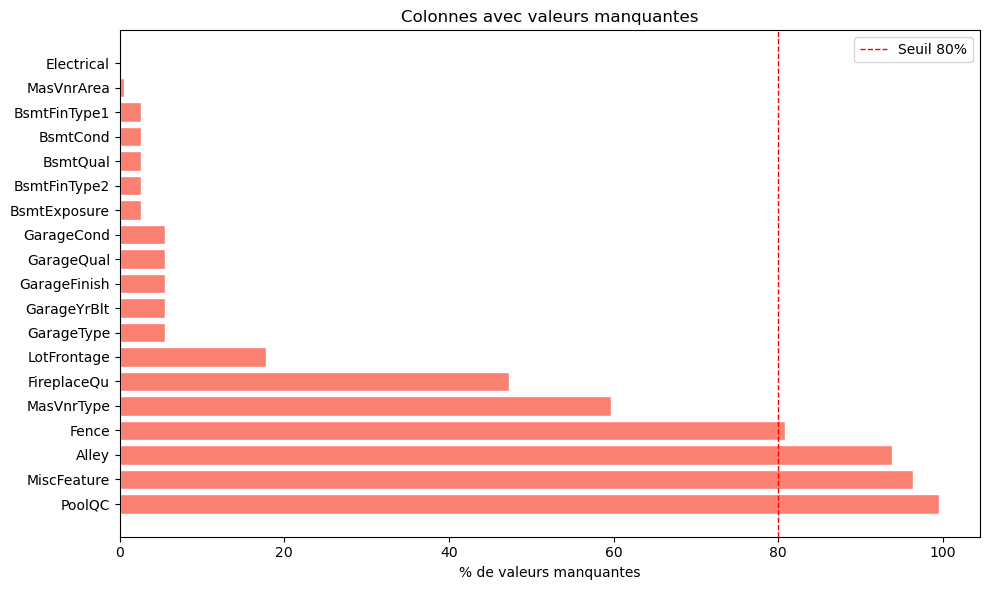

In [15]:
missing = (
    housing_data.isnull().sum()
    .pipe(lambda s: s[s > 0])
    .sort_values(ascending=False)
    .to_frame(name="NaN count")
    .assign(Pourcentage=lambda df: (df["NaN count"] / len(housing_data) * 100).round(2))
)
print(missing.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(missing.index, missing["Pourcentage"], color="salmon", edgecolor="white")
ax.axvline(80, color="red", linestyle="--", linewidth=1, label="Seuil 80%")
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("Colonnes avec valeurs manquantes")
ax.legend()
plt.tight_layout()
plt.show()

### 1.6 Heatmap des corrélations

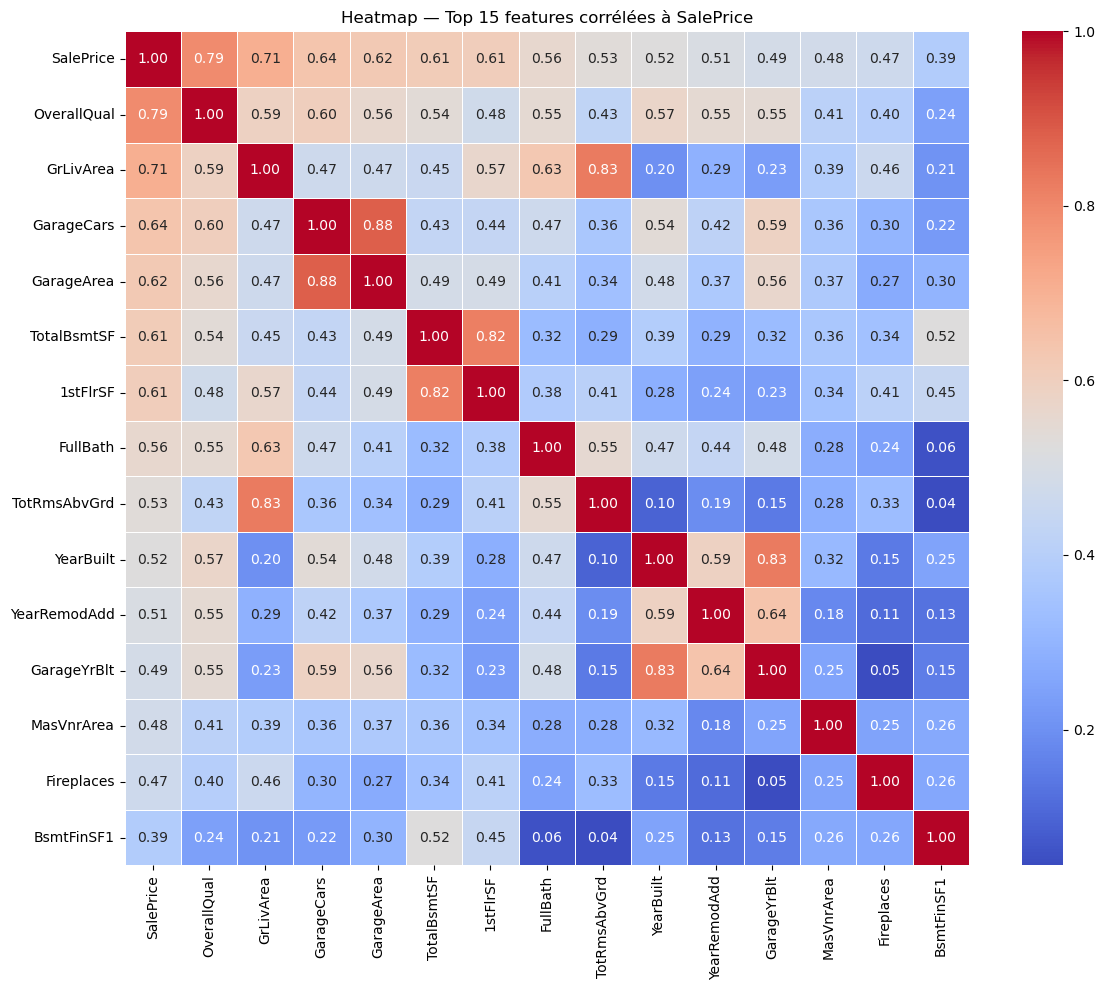

In [16]:
top_corr_cols = housing_data.select_dtypes(include="number").corr()["SalePrice"].abs().nlargest(15).index

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    housing_data[top_corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    ax=ax
)
ax.set_title("Heatmap — Top 15 features corrélées à SalePrice")
plt.tight_layout()
plt.show()

### 1.7 Top features corrélées à SalePrice

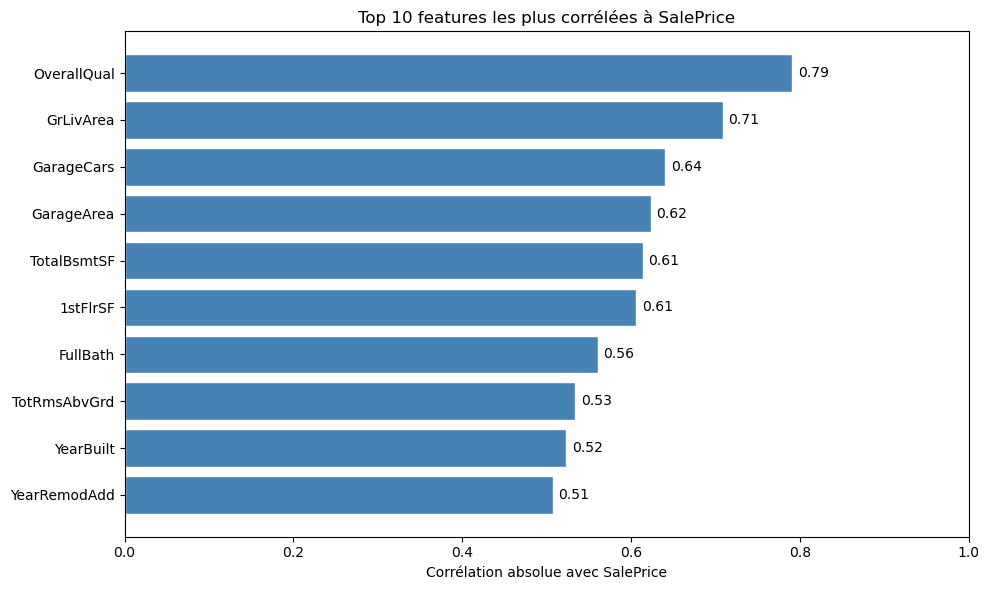

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101


In [17]:
correlations = (
    housing_data.select_dtypes(include="number")
    .corr()["SalePrice"]
    .drop("SalePrice")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(correlations.index[::-1], correlations.values[::-1], color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="%.2f", padding=4)
ax.set_xlabel("Corrélation absolue avec SalePrice")
ax.set_title("Top 10 features les plus corrélées à SalePrice")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print(correlations.to_string())

## 2. Nettoyage des données

### 2.1 Suppression des colonnes inutiles et trop incomplètes (> 80% NaN)

In [ ]:
df = housing_data.copy()

df.drop(columns=["Id"], inplace=True)

df["MSSubClass"] = df["MSSubClass"].astype(str)

threshold = 0.80 * len(df)
cols_to_drop = [col for col in df.columns if df[col].isnull().sum() > threshold]
df.drop(columns=cols_to_drop, inplace=True)

print(f"Colonnes supprimées (> 80% NaN) : {cols_to_drop}")
print(f"Shape après suppression : {df.shape}")

Colonnes supprimées (> 80% NaN) : ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
Shape après suppression : (1460, 76)


### 2.2 Imputation des valeurs manquantes

In [ ]:
cat_none_cols = [
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "FireplaceQu", "MasVnrType"
]
for col in cat_none_cols:
    if col in df.columns:
        df[col] = df[col].fillna("None")

num_zero_cols = [
    "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath", "GarageYrBlt", "GarageArea", "GarageCars"
]
for col in num_zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

remaining_nan = df.isnull().sum().sum()
print(f"NaN restants après imputation : {remaining_nan}")

NaN restants après imputation : 0


### 2.3 Détection et traitement des outliers

Outliers détectés (GrLivArea > 4000 & prix bas) : 2 lignes


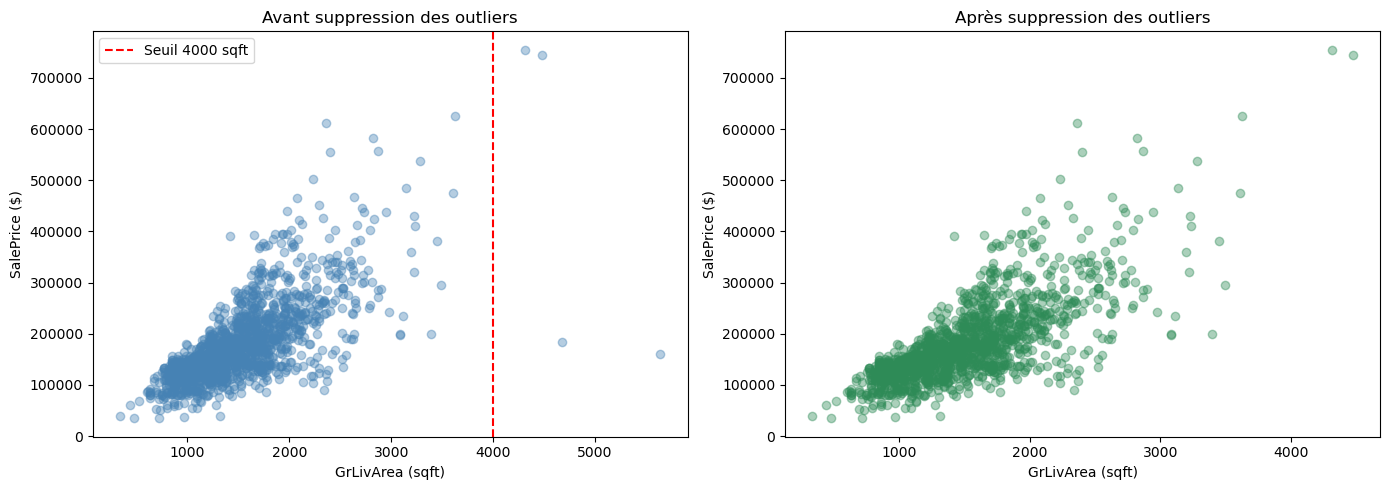

Shape final après nettoyage : (1458, 76)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["GrLivArea"], df["SalePrice"], alpha=0.4, color="steelblue")
axes[0].axvline(4000, color="red", linestyle="--", linewidth=1.5, label="Seuil 4000 sqft")
axes[0].set_xlabel("GrLivArea (sqft)")
axes[0].set_ylabel("SalePrice ($)")
axes[0].set_title("Avant suppression des outliers")
axes[0].legend()

outliers_mask = (df["GrLivArea"] > 4000) & (df["SalePrice"] < 300_000)
print(f"Outliers détectés (GrLivArea > 4000 & prix bas) : {outliers_mask.sum()} lignes")
df = df[~outliers_mask].reset_index(drop=True)

axes[1].scatter(df["GrLivArea"], df["SalePrice"], alpha=0.4, color="seagreen")
axes[1].set_xlabel("GrLivArea (sqft)")
axes[1].set_ylabel("SalePrice ($)")
axes[1].set_title("Après suppression des outliers")

plt.tight_layout()
plt.show()

print(f"Shape final après nettoyage : {df.shape}")

### 2.4 Encodage des variables catégorielles

In [ ]:
df["SalePrice"] = np.log1p(df["SalePrice"])

df_encoded = pd.get_dummies(df, drop_first=True).astype({
    col: int for col in pd.get_dummies(df, drop_first=True).select_dtypes(include="bool").columns
})

print(f"Shape avant encodage : {df.shape}")
print(f"Shape après encodage : {df_encoded.shape}")
df_encoded.head()

Shape avant encodage : (1458, 76)
Shape après encodage : (1458, 259)


,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,65.0,8450,7,5,2003,2003,196.0,706,0,150,...,0,0,0,0,1,0,0,0,1,0
1,80.0,9600,6,8,1976,1976,0.0,978,0,284,...,0,0,0,0,1,0,0,0,1,0
2,68.0,11250,7,5,2001,2002,162.0,486,0,434,...,0,0,0,0,1,0,0,0,1,0
3,60.0,9550,7,5,1915,1970,0.0,216,0,540,...,0,0,0,0,1,0,0,0,0,0
4,84.0,14260,8,5,2000,2000,350.0,655,0,490,...,0,0,0,0,1,0,0,0,1,0


## 3. Feature Engineering

### 3.1 Création de nouvelles features

In [25]:
df_encoded["TotalSF"]      = df_encoded["GrLivArea"] + df_encoded["TotalBsmtSF"]
df_encoded["HouseAge"]     = df_encoded["YrSold"] - df_encoded["YearBuilt"]
df_encoded["RemodAge"]     = df_encoded["YrSold"] - df_encoded["YearRemodAdd"]
df_encoded["TotalBath"]    = (
    df_encoded["FullBath"] + 0.5 * df_encoded["HalfBath"] +
    df_encoded["BsmtFullBath"] + 0.5 * df_encoded["BsmtHalfBath"]
)
df_encoded["HasGarage"]    = (df_encoded["GarageArea"] > 0).astype(int)
df_encoded["HasFireplace"] = (df_encoded["Fireplaces"] > 0).astype(int)

new_features = ["TotalSF", "HouseAge", "RemodAge", "TotalBath", "HasGarage", "HasFireplace"]
print("Nouvelles features créées :")
df_encoded[new_features].describe().round(2)

Nouvelles features créées :


,TotalSF,HouseAge,RemodAge,TotalBath,HasGarage,HasFireplace
count,1458.00,1458.00,1458.00,1458.00,1458.00,1458.00
mean,2563.00,36.60,22.98,2.21,0.94,0.53
std,776.19,30.24,20.64,0.78,0.23,0.50
min,334.00,0.00,0.00,1.00,0.00,0.00
25%,2014.00,8.00,4.00,2.00,1.00,0.00
50%,2476.50,35.00,14.00,2.00,1.00,1.00
75%,3005.50,54.00,41.00,2.50,1.00,1.00
max,6872.00,136.00,60.00,6.00,1.00,1.00


### 3.2 Sélection des features importantes

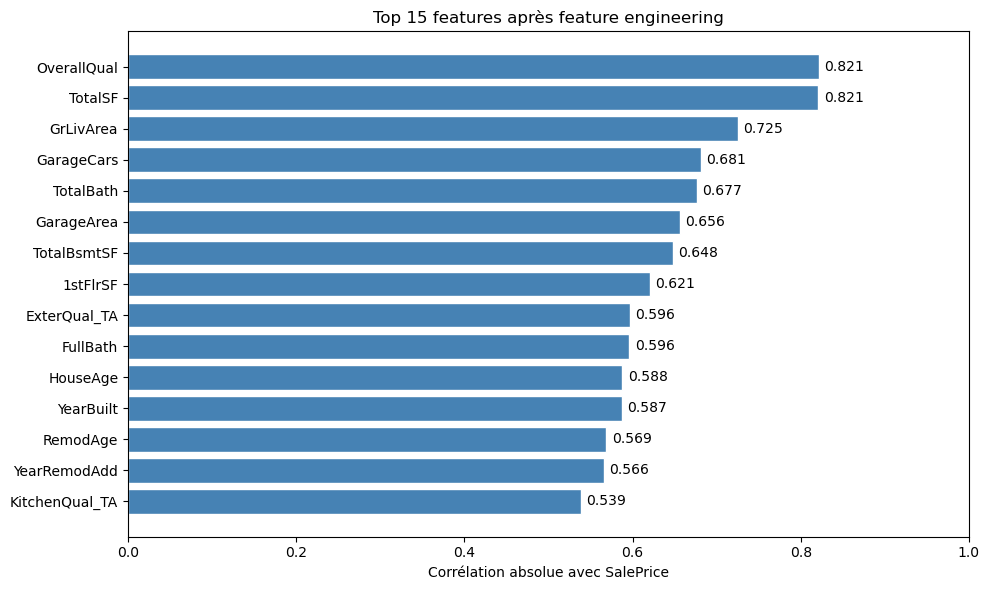

Features sélectionnées (|corr| > 0.1) : 138
X shape : (1458, 138)  |  y shape : (1458,)


In [26]:
correlations = (
    df_encoded.corr()["SalePrice"]
    .drop("SalePrice")
    .abs()
    .sort_values(ascending=False)
)

top_15 = correlations.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_15.index[::-1], top_15.values[::-1], color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set_xlabel("Corrélation absolue avec SalePrice")
ax.set_title("Top 15 features après feature engineering")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

selected_features = correlations[correlations > 0.1].index.tolist()
X = df_encoded[selected_features]
y = df_encoded["SalePrice"]
print(f"Features sélectionnées (|corr| > 0.1) : {len(selected_features)}")
print(f"X shape : {X.shape}  |  y shape : {y.shape}")

## 4. Entraînement des modèles

### 4.1 Séparation train / test

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train : {X_train.shape}  -  {len(X_train)} maisons")
print(f"Test  : {X_test.shape}   -  {len(X_test)} maisons")

Train : (1166, 138)  →  1166 maisons
Test  : (292, 138)   →  292 maisons
